# Анализ бенчмарков оптимизаторов транзакций

Сравнение алгоритмов **Greedy**, **Dinic** и **Edmonds–Karp** для обоснования выбора алгоритма в сервисе оптимизации транзакций (дипломная работа).

Данные: `dataset_greedy.csv`, `dataset_dinic.csv`, `dataset_karp.csv`, `dataset_pushrelabel.csv` (генерируются из Go-бенчмарков через `run.sh` и `bench_to_df.py`).

## Столбцы в датасете (CSV)

| Столбец | Описание |
|---------|----------|
| `algorithm` | Название алгоритма (Greedy, Dinic, EdmondsKarp, PushRelabel, Interactive Dinic, …) |
| `nodes` | Число узлов (участников) в тесте |
| `transactions` | Число транзакций в тесте |
| `ns_per_op` | Время на одну операцию, нс (основная метрика времени) |
| `collapse_pct` | Доля схлопнутых транзакций, % |
| `input_after_collapse` | Средний размер входа после схлопывания |
| `collapse_ns_per_op` | Время на схлопывание, нс/оп |
| `optimize_ns_per_op` | Время на оптимизацию, нс/оп |
| `reduce_success_pct` | Доля случаев, когда результат короче входа, % |
| `reduction_len_pct` | Средний % сокращения длины списка переводов |
| `valid_pct` | Доля валидных результатов (прошедших проверку), % |
| `bytes_per_op` | Байт на операцию (аллокации памяти) |
| `allocs_per_op` | Число аллокаций на операцию |
| `density` | Плотность: `transactions / (nodes × nodes)` |

In [101]:
# Установка зависимостей (выполнить один раз при первом запуске)
%pip install pandas matplotlib numpy --quiet

Note: you may need to restart the kernel to use updated packages.


In [102]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

# Путь к CSV: текущая папка (analitic) или типичные варианты при разных cwd
DATA_DIR = os.getcwd()
cwd = os.getcwd()
for d in [cwd, os.path.join(cwd, "analitic"), os.path.join(cwd, "ff-common", "optimizers", "tests", "analitic")]:
    if os.path.exists(os.path.join(d, "dataset_dinic.csv")):
        DATA_DIR = d
        break
print("DATA_DIR:", DATA_DIR)

def load_datasets():
    dfs = {}
    for name, f in [("Greedy", "dataset_greedy.csv"), ("Dinic", "dataset_dinic.csv"), ("EdmondsKarp", "dataset_karp.csv"), ("PushRelabel", "dataset_pushrelabel.csv"), ("Interactive Dinic", "dataset_interactive_dinic.csv"), ("Interactive EdmondsKarp", "dataset_interactive_karp.csv"), ("Interactive PushRelabel", "dataset_interactive_pushrelabel.csv")]:
        path = os.path.join(DATA_DIR, f)
        if os.path.exists(path):
            dfs[name] = pd.read_csv(path)
        else:
            print(f"Файл не найден: {path}")
    return dfs

datasets = load_datasets()
if datasets:
    df_all = pd.concat(datasets.values(), ignore_index=True)
    print("Загружено строк по алгоритмам:")
    print(df_all.groupby("algorithm").size())
    print(df_all.head())
else:
    df_all = pd.DataFrame()

# Фиксированные размерности из Go-бенчмарка (nodesForSweep, transValuesForSweep)
NODES_SWEEP = [5, 10, 25, 50, 100, 200]
TRANS_SWEEP = list(range(10, 101, 10)) + list(range(1000, 10001, 1000))

DATA_DIR: /Users/ivasnev/Some Projects/FinFlow/ff-common/optimizers/tests/analitic
Загружено строк по алгоритмам:
algorithm
Dinic                      120
EdmondsKarp                120
Greedy                     120
Interactive Dinic          120
Interactive EdmondsKarp    120
Interactive PushRelabel    120
PushRelabel                120
dtype: int64
  algorithm  nodes  transactions  ns_per_op  collapse_pct  \
0    Greedy      5            10    22178.0         34.82   
1    Greedy      5            20    25498.0         56.10   
2    Greedy      5            30    27077.0         68.10   
3    Greedy      5            40    28121.0         75.39   
4    Greedy      5            50    29131.0         80.12   

   input_after_collapse  collapse_ns_per_op  optimize_ns_per_op  \
0                 6.518              1817.0              7935.0   
1                 8.780              2705.0             10040.0   
2                 9.569              3419.0             10613.0   
3          

In [103]:
# Проверка пропусков: какие (nodes, trans) отсутствуют в данных по каждому алгоритму
# Серые ячейки на тепловых картах = нет данных (прогон не попал в CSV или не распарсился)
import itertools
expected = set(itertools.product(NODES_SWEEP, TRANS_SWEEP))
for algo in df_all["algorithm"].unique():
    present = set(zip(df_all[df_all["algorithm"] == algo]["nodes"], df_all[df_all["algorithm"] == algo]["transactions"]))
    missing = sorted(expected - present)
    if missing:
        print(f"{algo}: пропущено {len(missing)} из {len(expected)} — {missing[:15]}{'...' if len(missing) > 15 else ''}")
    else:
        print(f"{algo}: полная сетка")

Greedy: полная сетка
Dinic: полная сетка
EdmondsKarp: полная сетка
PushRelabel: полная сетка
Interactive Dinic: полная сетка
Interactive EdmondsKarp: полная сетка
Interactive PushRelabel: полная сетка


## Блок 1: Время выполнения и число транзакций

Графики зависимости времени (мкс/оп) от числа транзакций для фиксированных чисел узлов: 5, 10, 25, 50, 100, 200 (nodesForSweep из бенчмарка). На каждом графике — все алгоритмы для сравнения.

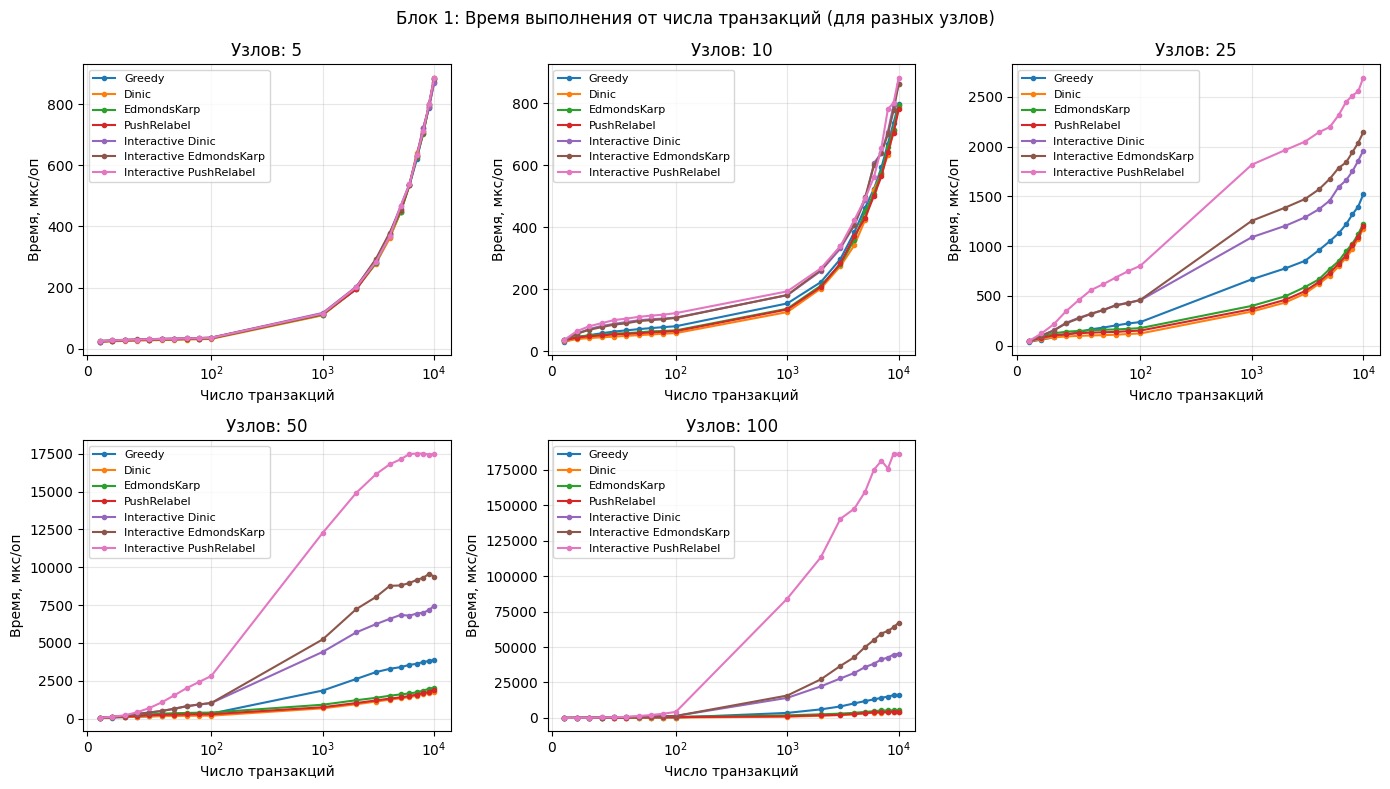

In [104]:
NODES_FOR_PLOTS = NODES_SWEEP  # [5, 10, 25, 50, 100, 200] — как nodesForSweep в random_test.go
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, n in enumerate(NODES_FOR_PLOTS):
    sub = df_all[df_all["nodes"] == n].copy()
    if sub.empty:
        axes[i].set_visible(False)
        continue
    for algo in ["Greedy", "Dinic", "EdmondsKarp", "PushRelabel", "Interactive Dinic", "Interactive EdmondsKarp", "Interactive PushRelabel"]:
        d = sub[sub["algorithm"] == algo].sort_values("transactions")
        if d.empty:
            continue
        axes[i].plot(d["transactions"], d["ns_per_op"] / 1000, "o-", label=algo, markersize=3)
    axes[i].set_xlabel("Число транзакций")
    axes[i].set_ylabel("Время, мкс/оп")
    axes[i].set_title(f"Узлов: {n}")
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xscale("symlog", linthresh=100)
axes[5].set_visible(False)
plt.suptitle("Блок 1: Время выполнения от числа транзакций (для разных узлов)")
plt.tight_layout()
plt.show()

## Блок 2: Аллокации и число транзакций

Графики зависимости числа аллокаций на операцию от числа транзакций для тех же узлов (5, 10, 25, 50, 100, 200). Меньше аллокаций — меньше нагрузка на сборщик мусора.

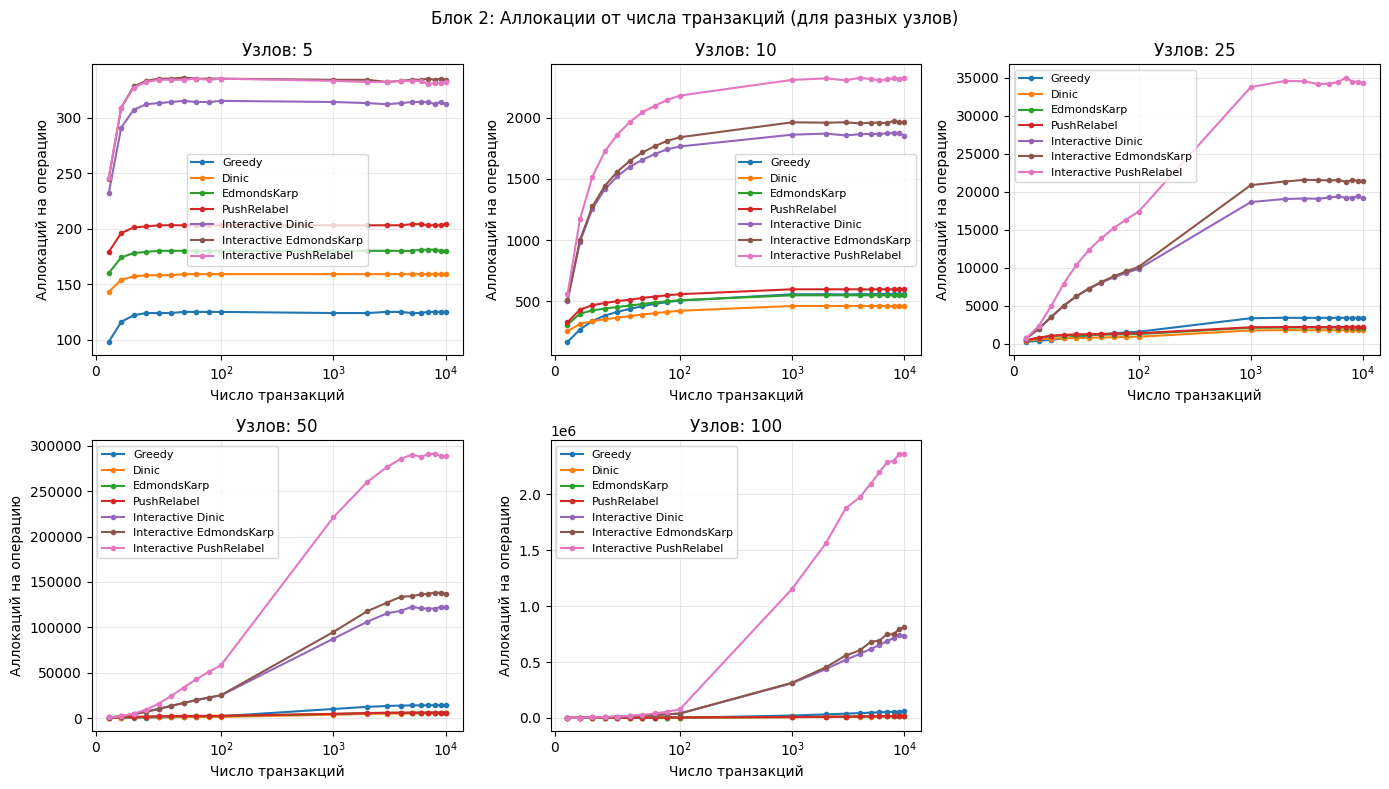

In [105]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, n in enumerate(NODES_FOR_PLOTS):
    sub = df_all[df_all["nodes"] == n].copy()
    if sub.empty:
        axes[i].set_visible(False)
        continue
    for algo in ["Greedy", "Dinic", "EdmondsKarp", "PushRelabel", "Interactive Dinic", "Interactive EdmondsKarp", "Interactive PushRelabel"]:
        d = sub[sub["algorithm"] == algo].sort_values("transactions")
        if d.empty:
            continue
        axes[i].plot(d["transactions"], d["allocs_per_op"], "o-", label=algo, markersize=3)
    axes[i].set_xlabel("Число транзакций")
    axes[i].set_ylabel("Аллокаций на операцию")
    axes[i].set_title(f"Узлов: {n}")
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xscale("symlog", linthresh=100)
axes[5].set_visible(False)
plt.suptitle("Блок 2: Аллокации от числа транзакций (для разных узлов)")
plt.tight_layout()
plt.show()

## Блок 3: Тепловые карты

Все тепловые карты в одном месте для удобного сравнения.

1. **Время (нс/оп)** — по каждому алгоритму на общей шкале + отношение Karp/Dinic (красный = Karp медленнее).
2. **Качество (reduction_len_pct)** — средний % сокращения числа переводов; выше — лучше; у Greedy может быть отрицательным.
3. **Память: аллокации (allocs/op)** и **байты (KB/op)** — общая шкала по всем алгоритмам.

/var/folders/m0/zjh05d5n2b31m7h70ln7rjcr0000gn/T/ipykernel_26209/3137679176.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap(cmap_name).copy()


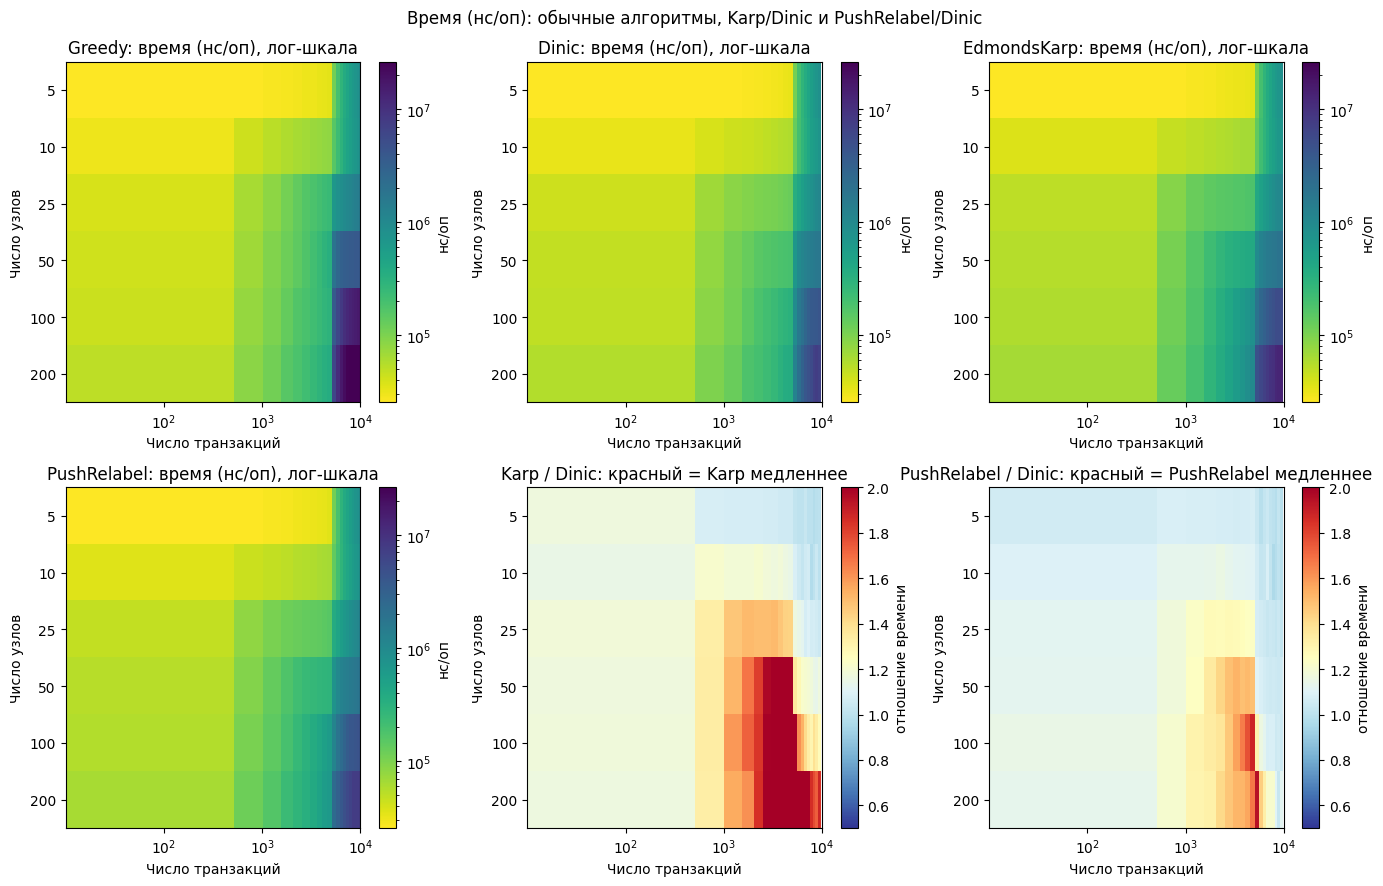

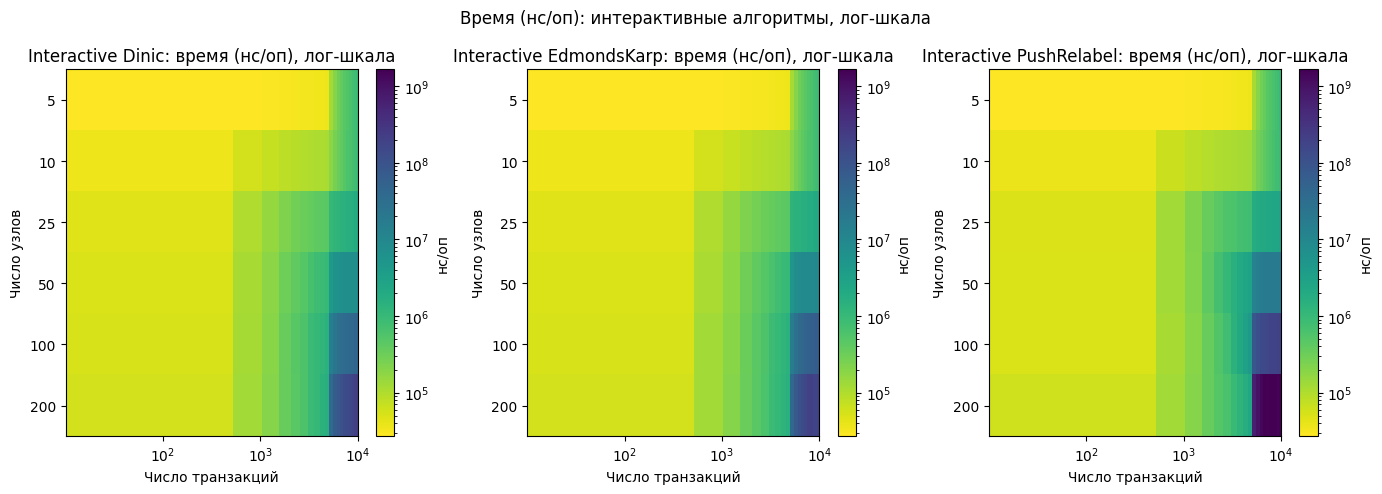

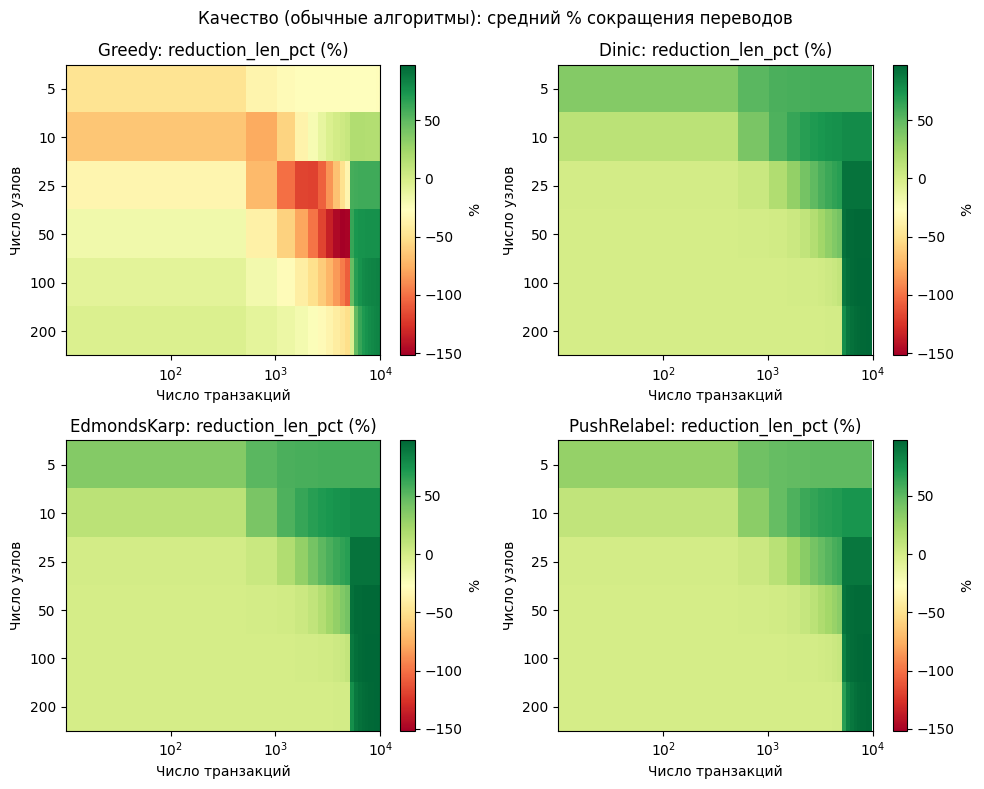

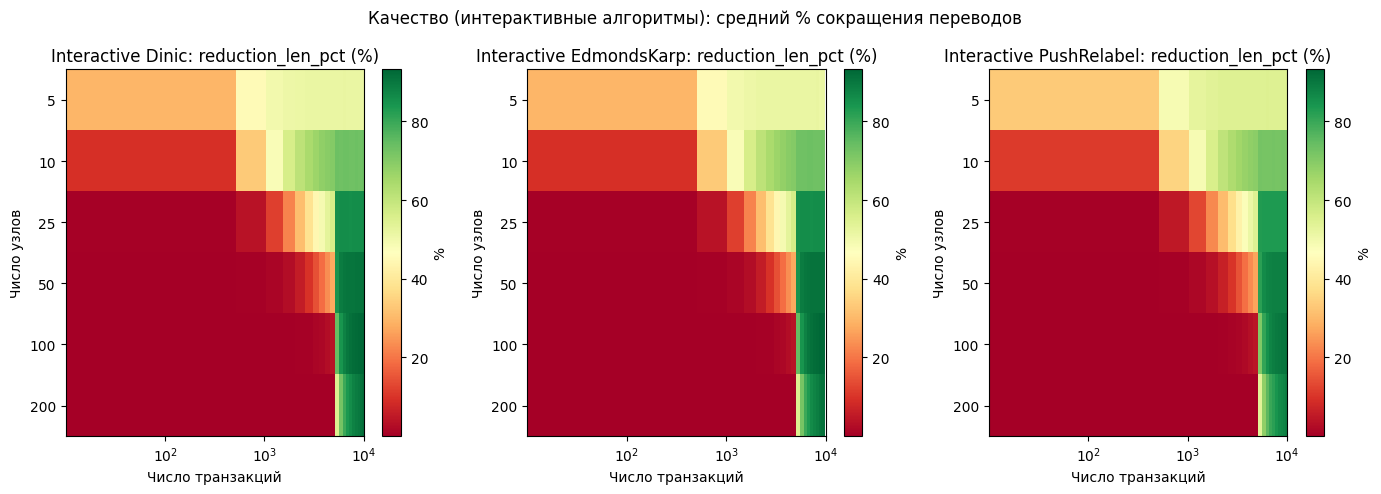

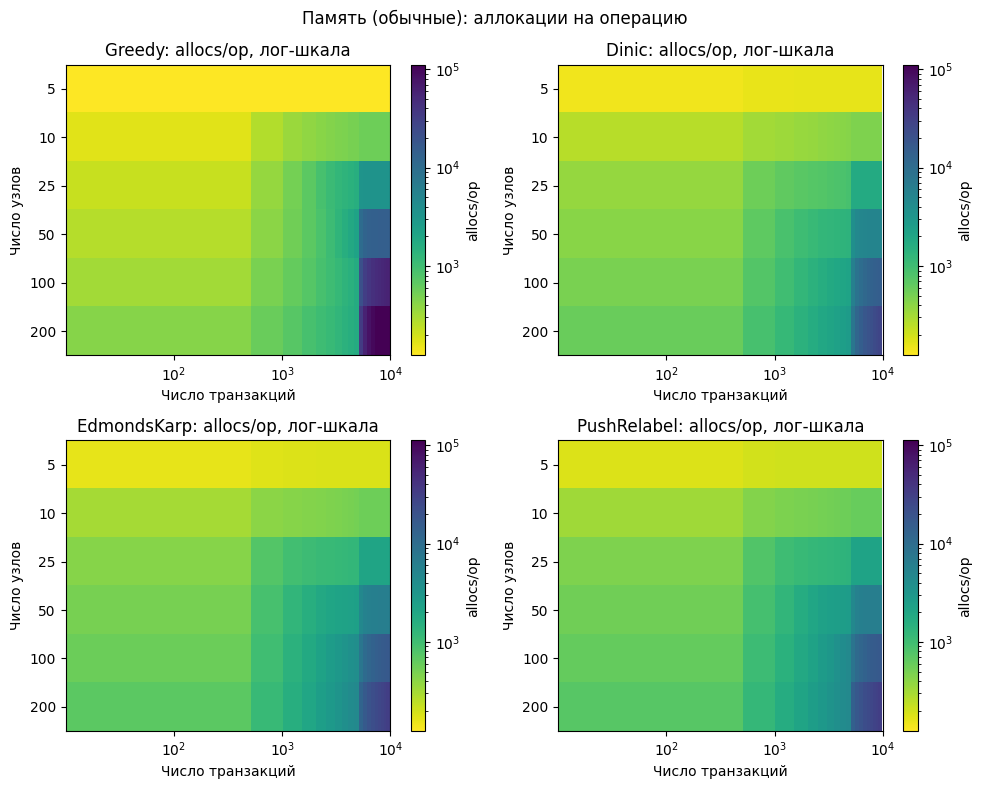

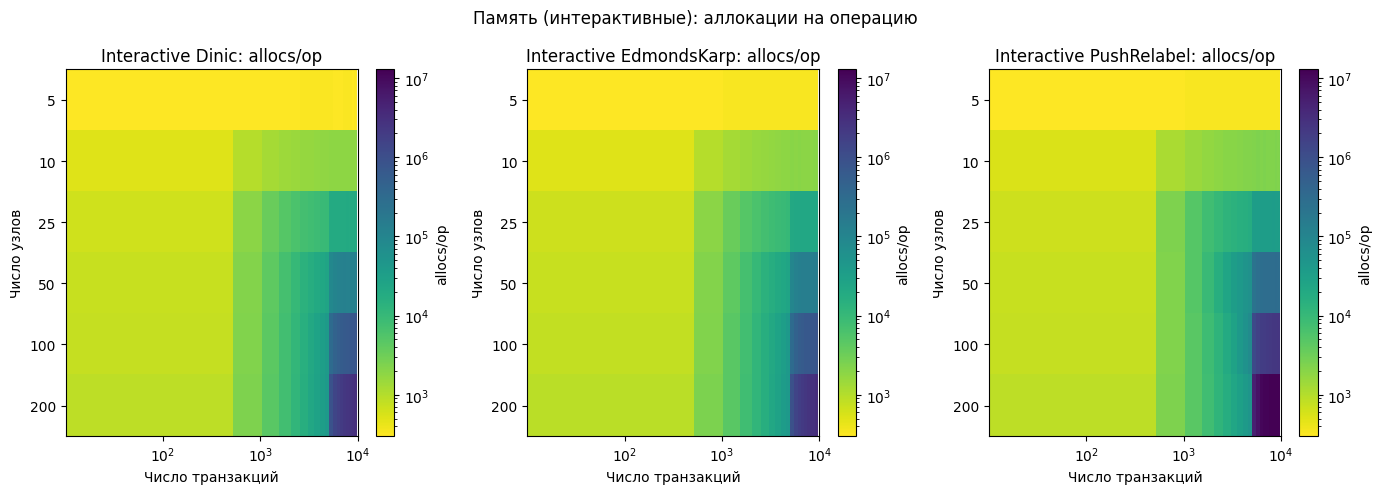

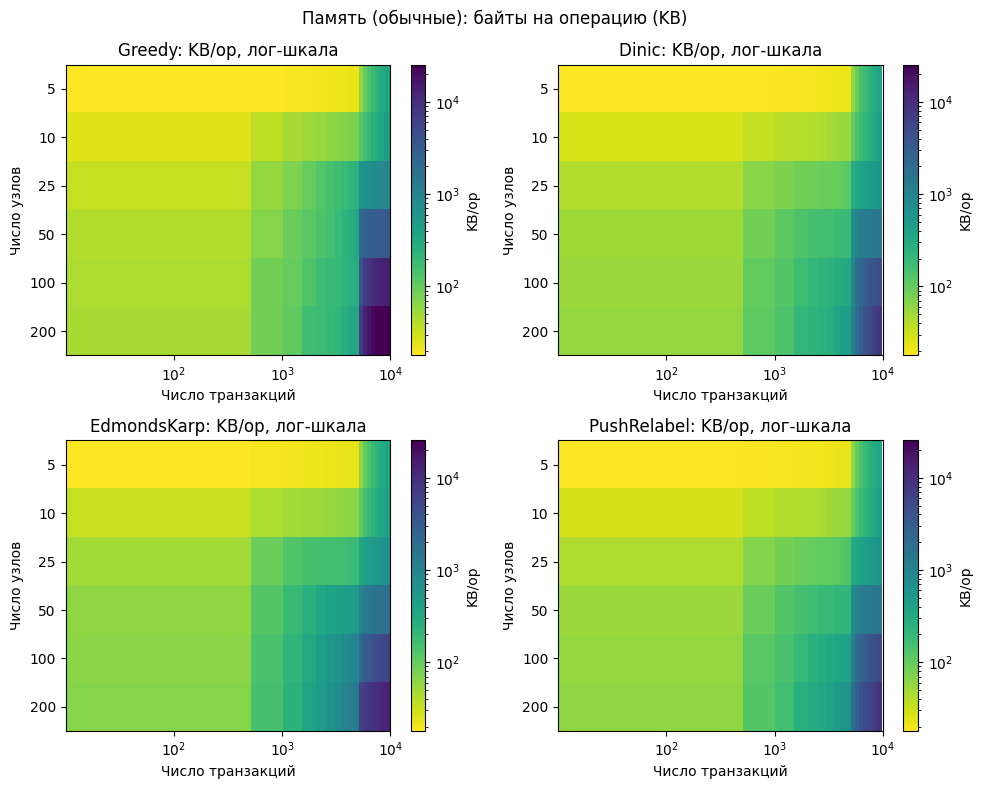

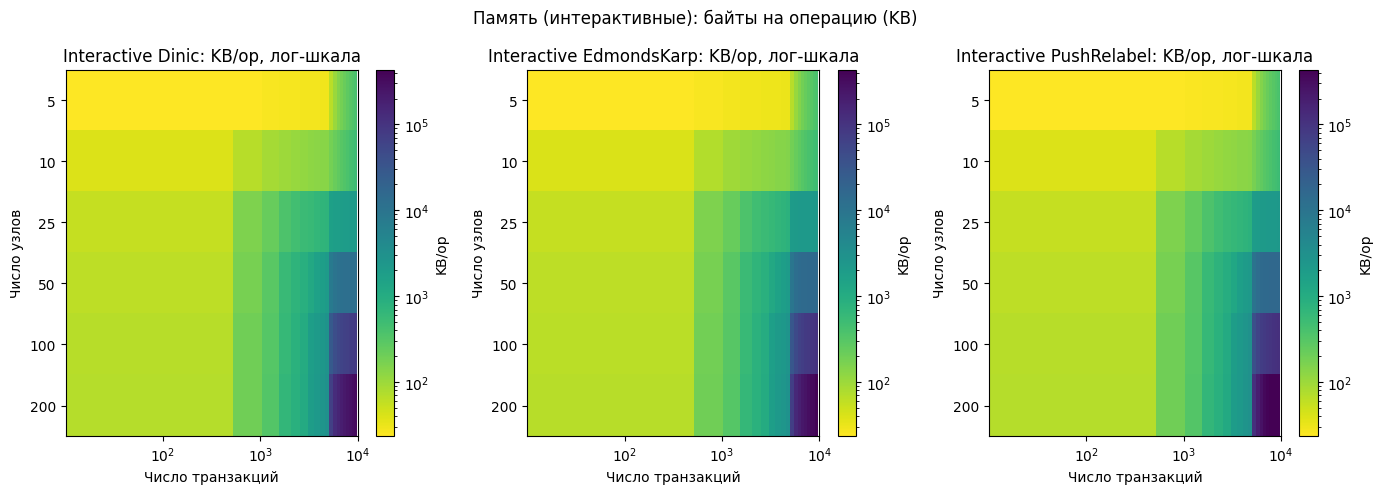

In [106]:
def pivot_metric(df, metric="ns_per_op"):
    pt = df.pivot_table(index="nodes", columns="transactions", values=metric, aggfunc="mean")
    # Фиксированная сетка как в Go: nodesForSweep × transValuesForSweep
    return pt.reindex(index=NODES_SWEEP, columns=TRANS_SWEEP).sort_index(axis=0).sort_index(axis=1)

def set_heatmap_axis_ticks(ax, node_vals, trans_vals):
    """Подписи оси Y тепловой карты — только node_vals (5, 10, 25, 50, 100, 200), без 75, 125, 150."""
    n = len(node_vals)
    y_centers = [node_vals[0] + (node_vals[-1] - node_vals[0]) * (i + 0.5) / n for i in range(n)]
    ax.set_yticks(y_centers)
    ax.set_yticklabels(node_vals)

# Пропуски (NaN) на тепловых картах — серый цвет, чтобы не путать с белым/нулём
def _cmap_bad(cmap_name, bad_color='lightgray'):
    cm = plt.cm.get_cmap(cmap_name).copy()
    cm.set_bad(color=bad_color)
    return cm
CMAP_TIME = _cmap_bad('viridis_r')
CMAP_RATIO = _cmap_bad('RdYlBu_r')
CMAP_QUAL = _cmap_bad('RdYlGn')
CMAP_OTHER = _cmap_bad('viridis')

# Лог-шкала для метрик с большим разбросом (время, байты, аллокации) — раскраска по относительным различиям
def _log_norm(vals, p_low=1, p_high=99):
    arr = np.asarray(vals).astype(float).flatten()
    arr = arr[np.isfinite(arr) & (arr > 0)]
    if arr.size == 0:
        return LogNorm(1, 10)
    vmin = max(1.0, np.percentile(arr, p_low))
    vmax = np.percentile(arr, p_high)
    if vmax <= vmin:
        vmax = vmin * 10
    return LogNorm(vmin=vmin, vmax=vmax)

# Тепловые карты времени: обычные алгоритмы и интерактивные — отдельно (у интерактивных время сильно выше)
ALGOS_REGULAR = ["Greedy", "Dinic", "EdmondsKarp", "PushRelabel"]
ALGOS_INTERACTIVE = ["Interactive Dinic", "Interactive EdmondsKarp", "Interactive PushRelabel"]

# Обычные алгоритмы — своя шкала
all_times_r = []
for algo in ALGOS_REGULAR:
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub).sort_index(axis=0).sort_index(axis=1)
    if not mat.empty:
        all_times_r.append(mat.values)
norm_r = _log_norm(np.concatenate(all_times_r)) if all_times_r else LogNorm(1, 10)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
ax_list = axes.flatten()
for idx, algo in enumerate(ALGOS_REGULAR):
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub).sort_index(axis=0).sort_index(axis=1)
    if mat.empty:
        continue
    nodes, trans = mat.index.values, mat.columns.values
    Z = mat.values
    im = ax_list[idx].imshow(Z, aspect="auto", cmap=CMAP_TIME, norm=norm_r,
                             extent=[trans.min(), trans.max(), nodes.max(), nodes.min()])
    ax_list[idx].set_xscale("symlog", linthresh=100)
    ax_list[idx].set_xlabel("Число транзакций")
    ax_list[idx].set_ylabel("Число узлов")
    ax_list[idx].set_title(f"{algo}: время (нс/оп), лог-шкала")
    set_heatmap_axis_ticks(ax_list[idx], NODES_SWEEP, TRANS_SWEEP)
    plt.colorbar(im, ax=ax_list[idx], label="нс/оп")
p_dinic = pivot_metric(df_all[df_all["algorithm"] == "Dinic"]).sort_index(axis=0).sort_index(axis=1)
p_karp  = pivot_metric(df_all[df_all["algorithm"] == "EdmondsKarp"]).sort_index(axis=0).sort_index(axis=1)
p_pr    = pivot_metric(df_all[df_all["algorithm"] == "PushRelabel"]).sort_index(axis=0).sort_index(axis=1)
common_idx = p_dinic.index.intersection(p_karp.index).intersection(p_pr.index)
common_col = p_dinic.columns.intersection(p_karp.columns).intersection(p_pr.columns)
p_d = p_dinic.reindex(index=common_idx, columns=common_col)
p_k = p_karp.reindex(index=common_idx, columns=common_col)
p_p = p_pr.reindex(index=common_idx, columns=common_col)
ratio_kd = p_k.values / (p_d.values + 1e-9)
ratio_pr = p_p.values / (p_d.values + 1e-9)
nodes, trans = p_d.index.values, p_d.columns.values
im = ax_list[4].imshow(ratio_kd, aspect="auto", cmap=CMAP_RATIO, vmin=0.5, vmax=2,
                       extent=[trans.min(), trans.max(), nodes.max(), nodes.min()])
ax_list[4].set_xscale("symlog", linthresh=100)
ax_list[4].set_xlabel("Число транзакций")
ax_list[4].set_ylabel("Число узлов")
ax_list[4].set_title("Karp / Dinic: красный = Karp медленнее")
set_heatmap_axis_ticks(ax_list[4], NODES_SWEEP, TRANS_SWEEP)
plt.colorbar(im, ax=ax_list[4], label="отношение времени")
im = ax_list[5].imshow(ratio_pr, aspect="auto", cmap=CMAP_RATIO, vmin=0.5, vmax=2,
                       extent=[trans.min(), trans.max(), nodes.max(), nodes.min()])
ax_list[5].set_xscale("symlog", linthresh=100)
ax_list[5].set_xlabel("Число транзакций")
ax_list[5].set_ylabel("Число узлов")
ax_list[5].set_title("PushRelabel / Dinic: красный = PushRelabel медленнее")
set_heatmap_axis_ticks(ax_list[5], NODES_SWEEP, TRANS_SWEEP)
plt.colorbar(im, ax=ax_list[5], label="отношение времени")
plt.suptitle("Время (нс/оп): обычные алгоритмы, Karp/Dinic и PushRelabel/Dinic")
plt.tight_layout()
plt.show()

# Интерактивные алгоритмы — своя шкала (время существенно выше)
all_times_i = []
for algo in ALGOS_INTERACTIVE:
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub).sort_index(axis=0).sort_index(axis=1)
    if not mat.empty:
        all_times_i.append(mat.values)
if all_times_i:
    norm_i = _log_norm(np.concatenate(all_times_i))
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    for idx, algo in enumerate(ALGOS_INTERACTIVE):
        sub = df_all[df_all["algorithm"] == algo]
        mat = pivot_metric(sub).sort_index(axis=0).sort_index(axis=1)
        if mat.empty:
            continue
        nodes, trans = mat.index.values, mat.columns.values
        im = axes[idx].imshow(mat.values, aspect="auto", cmap=CMAP_TIME, norm=norm_i,
                             extent=[trans.min(), trans.max(), nodes.max(), nodes.min()])
        axes[idx].set_xscale("symlog", linthresh=100)
        axes[idx].set_xlabel("Число транзакций")
        axes[idx].set_ylabel("Число узлов")
        axes[idx].set_title(f"{algo}: время (нс/оп), лог-шкала")
        set_heatmap_axis_ticks(axes[idx], NODES_SWEEP, TRANS_SWEEP)
        plt.colorbar(im, ax=axes[idx], label="нс/оп")
    plt.suptitle("Время (нс/оп): интерактивные алгоритмы, лог-шкала")
    plt.tight_layout()
    plt.show()

# 2) Качество: reduction_len_pct (обычные и интерактивные — отдельно)
all_red_r = []
for algo in ALGOS_REGULAR:
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub, metric="reduction_len_pct").sort_index(axis=0).sort_index(axis=1)
    if not mat.empty:
        all_red_r.append(mat.values)
rmin_r = np.nanmin(np.concatenate(all_red_r)) if all_red_r else 0
rmax_r = np.nanmax(np.concatenate(all_red_r)) if all_red_r else 100
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for idx, algo in enumerate(ALGOS_REGULAR):
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub, metric="reduction_len_pct").sort_index(axis=0).sort_index(axis=1)
    if mat.empty:
        continue
    nodes, trans = mat.index.values, mat.columns.values
    im = axes[idx].imshow(mat.values, aspect="auto", cmap=CMAP_QUAL, vmin=rmin_r, vmax=rmax_r,
                          extent=[trans.min(), trans.max(), nodes.max(), nodes.min()])
    axes[idx].set_xscale("symlog", linthresh=100)
    axes[idx].set_xlabel("Число транзакций")
    axes[idx].set_ylabel("Число узлов")
    axes[idx].set_title(f"{algo}: reduction_len_pct (%)")
    set_heatmap_axis_ticks(axes[idx], NODES_SWEEP, TRANS_SWEEP)
    plt.colorbar(im, ax=axes[idx], label="%")
plt.suptitle("Качество (обычные алгоритмы): средний % сокращения переводов")
plt.tight_layout()
plt.show()
all_red_i = []
for algo in ALGOS_INTERACTIVE:
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub, metric="reduction_len_pct").sort_index(axis=0).sort_index(axis=1)
    if not mat.empty:
        all_red_i.append(mat.values)
if all_red_i:
    rmin_i = np.nanmin(np.concatenate(all_red_i))
    rmax_i = np.nanmax(np.concatenate(all_red_i))
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    for idx, algo in enumerate(ALGOS_INTERACTIVE):
        sub = df_all[df_all["algorithm"] == algo]
        mat = pivot_metric(sub, metric="reduction_len_pct").sort_index(axis=0).sort_index(axis=1)
        if mat.empty:
            continue
        nodes, trans = mat.index.values, mat.columns.values
        im = axes[idx].imshow(mat.values, aspect="auto", cmap=CMAP_QUAL, vmin=rmin_i, vmax=rmax_i,
                              extent=[trans.min(), trans.max(), nodes.max(), nodes.min()])
        axes[idx].set_xscale("symlog", linthresh=100)
        axes[idx].set_xlabel("Число транзакций")
        axes[idx].set_ylabel("Число узлов")
        axes[idx].set_title(f"{algo}: reduction_len_pct (%)")
        set_heatmap_axis_ticks(axes[idx], NODES_SWEEP, TRANS_SWEEP)
        plt.colorbar(im, ax=axes[idx], label="%")
    plt.suptitle("Качество (интерактивные алгоритмы): средний % сокращения переводов")
    plt.tight_layout()
    plt.show()

# 3) Память: allocs_per_op (обычные и интерактивные — отдельно)
all_allocs_r = []
for algo in ALGOS_REGULAR:
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub, metric="allocs_per_op").sort_index(axis=0).sort_index(axis=1)
    if not mat.empty:
        all_allocs_r.append(mat.values)
norm_allocs_r = _log_norm(np.concatenate(all_allocs_r)) if all_allocs_r else LogNorm(1, 10)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for idx, algo in enumerate(ALGOS_REGULAR):
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub, metric="allocs_per_op").sort_index(axis=0).sort_index(axis=1)
    if mat.empty:
        continue
    nodes, trans = mat.index.values, mat.columns.values
    im = axes[idx].imshow(mat.values, aspect="auto", cmap=CMAP_TIME, norm=norm_allocs_r,
                          extent=[trans.min(), trans.max(), nodes.max(), nodes.min()])
    axes[idx].set_xscale("symlog", linthresh=100)
    axes[idx].set_xlabel("Число транзакций")
    axes[idx].set_ylabel("Число узлов")
    axes[idx].set_title(f"{algo}: allocs/op, лог-шкала")
    set_heatmap_axis_ticks(axes[idx], NODES_SWEEP, TRANS_SWEEP)
    plt.colorbar(im, ax=axes[idx], label="allocs/op")
plt.suptitle("Память (обычные): аллокации на операцию")
plt.tight_layout()
plt.show()
all_allocs_i = []
for algo in ALGOS_INTERACTIVE:
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub, metric="allocs_per_op").sort_index(axis=0).sort_index(axis=1)
    if not mat.empty:
        all_allocs_i.append(mat.values)
if all_allocs_i:
    norm_allocs_i = _log_norm(np.concatenate(all_allocs_i))
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    for idx, algo in enumerate(ALGOS_INTERACTIVE):
        sub = df_all[df_all["algorithm"] == algo]
        mat = pivot_metric(sub, metric="allocs_per_op").sort_index(axis=0).sort_index(axis=1)
        if mat.empty:
            continue
        nodes, trans = mat.index.values, mat.columns.values
        im = axes[idx].imshow(mat.values, aspect="auto", cmap=CMAP_TIME, norm=norm_allocs_i,
                              extent=[trans.min(), trans.max(), nodes.max(), nodes.min()])
        axes[idx].set_xscale("symlog", linthresh=100)
        axes[idx].set_xlabel("Число транзакций")
        axes[idx].set_ylabel("Число узлов")
        axes[idx].set_title(f"{algo}: allocs/op")
        set_heatmap_axis_ticks(axes[idx], NODES_SWEEP, TRANS_SWEEP)
        plt.colorbar(im, ax=axes[idx], label="allocs/op")
    plt.suptitle("Память (интерактивные): аллокации на операцию")
    plt.tight_layout()
    plt.show()

# 4) Память: bytes (KB) (обычные и интерактивные — отдельно)
df_all["bytes_kb"] = df_all["bytes_per_op"] / 1024
all_bytes_r = []
for algo in ALGOS_REGULAR:
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub, metric="bytes_kb").sort_index(axis=0).sort_index(axis=1)
    if not mat.empty:
        all_bytes_r.append(mat.values)
norm_bytes_r = _log_norm(np.concatenate(all_bytes_r)) if all_bytes_r else LogNorm(1, 10)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for idx, algo in enumerate(ALGOS_REGULAR):
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub, metric="bytes_kb").sort_index(axis=0).sort_index(axis=1)
    if mat.empty:
        continue
    nodes, trans = mat.index.values, mat.columns.values
    im = axes[idx].imshow(mat.values, aspect="auto", cmap=CMAP_TIME, norm=norm_bytes_r,
                          extent=[trans.min(), trans.max(), nodes.max(), nodes.min()])
    axes[idx].set_xscale("symlog", linthresh=100)
    axes[idx].set_xlabel("Число транзакций")
    axes[idx].set_ylabel("Число узлов")
    axes[idx].set_title(f"{algo}: KB/op, лог-шкала")
    set_heatmap_axis_ticks(axes[idx], NODES_SWEEP, TRANS_SWEEP)
    plt.colorbar(im, ax=axes[idx], label="KB/op")
plt.suptitle("Память (обычные): байты на операцию (KB)")
plt.tight_layout()
plt.show()
all_bytes_i = []
for algo in ALGOS_INTERACTIVE:
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub, metric="bytes_kb").sort_index(axis=0).sort_index(axis=1)
    if not mat.empty:
        all_bytes_i.append(mat.values)
if all_bytes_i:
    norm_bytes_i = _log_norm(np.concatenate(all_bytes_i))
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    for idx, algo in enumerate(ALGOS_INTERACTIVE):
        sub = df_all[df_all["algorithm"] == algo]
        mat = pivot_metric(sub, metric="bytes_kb").sort_index(axis=0).sort_index(axis=1)
        if mat.empty:
            continue
        nodes, trans = mat.index.values, mat.columns.values
        im = axes[idx].imshow(mat.values, aspect="auto", cmap=CMAP_TIME, norm=norm_bytes_i,
                              extent=[trans.min(), trans.max(), nodes.max(), nodes.min()])
        axes[idx].set_xscale("symlog", linthresh=100)
        axes[idx].set_xlabel("Число транзакций")
        axes[idx].set_ylabel("Число узлов")
        axes[idx].set_title(f"{algo}: KB/op, лог-шкала")
        set_heatmap_axis_ticks(axes[idx], NODES_SWEEP, TRANS_SWEEP)
        plt.colorbar(im, ax=axes[idx], label="KB/op")
    plt.suptitle("Память (интерактивные): байты на операцию (KB)")
    plt.tight_layout()
    plt.show()

## Блок 4: Дополнительные метрики (тепловые карты)

Тепловые карты по метрикам: **collapse_pct** (доля схлопнутых транзакций), **input_after_collapse** (средний размер входа после схлопывания), **collapse_ns_per_op** и **optimize_ns_per_op** (время на схлопывание и на оптимизацию). Для каждой метрики — три карты (по алгоритмам) на общей шкале.

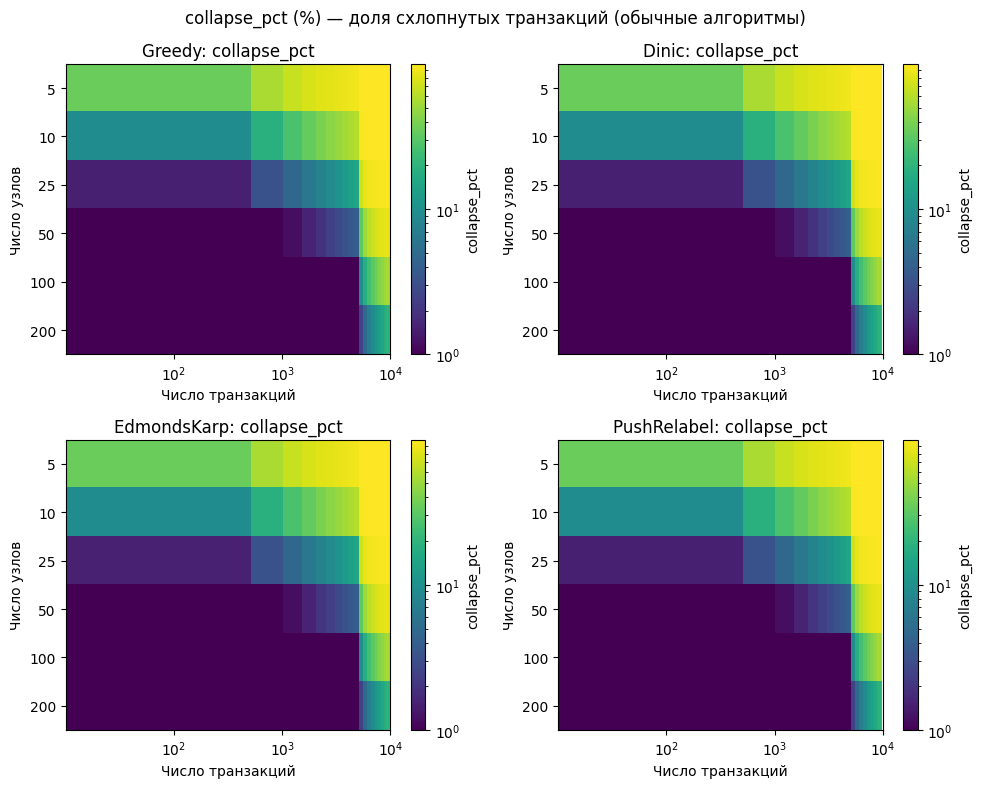

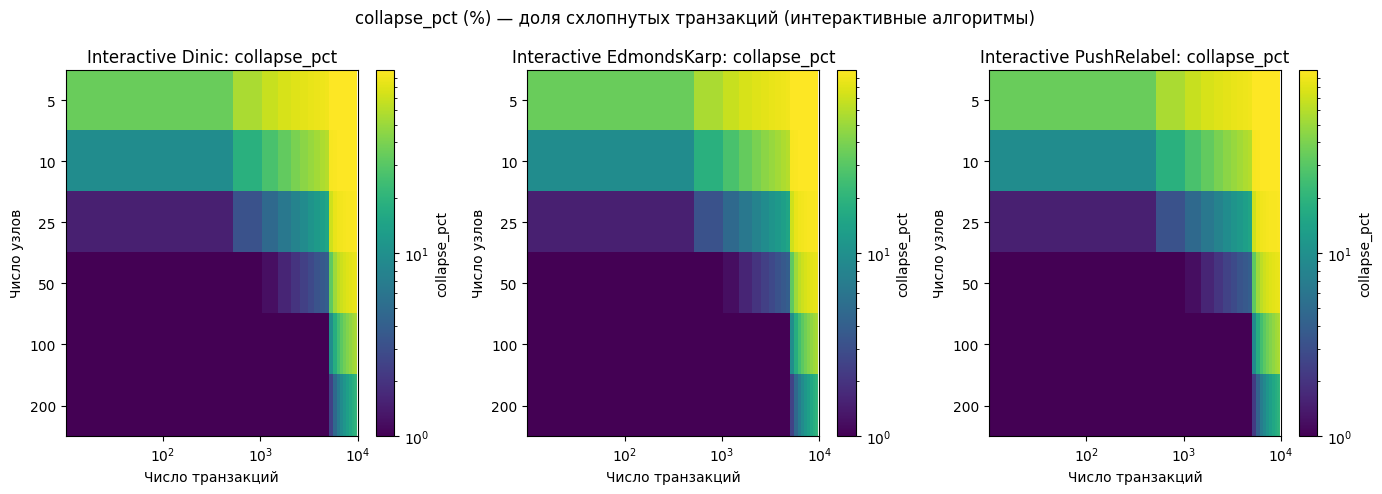

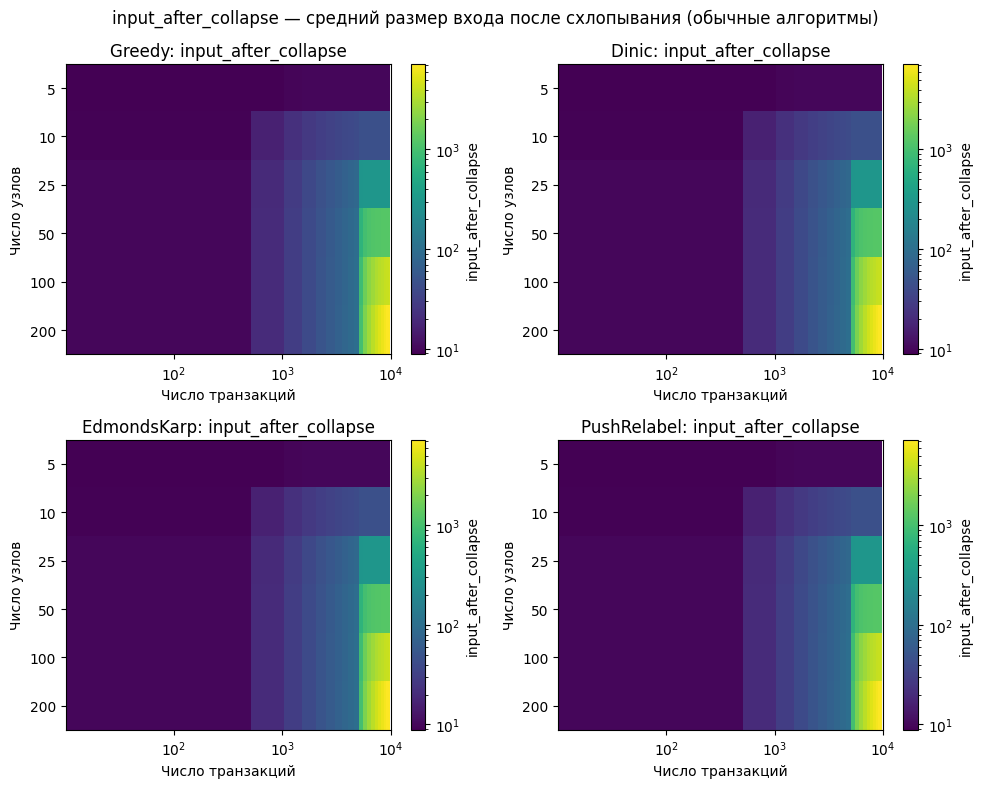

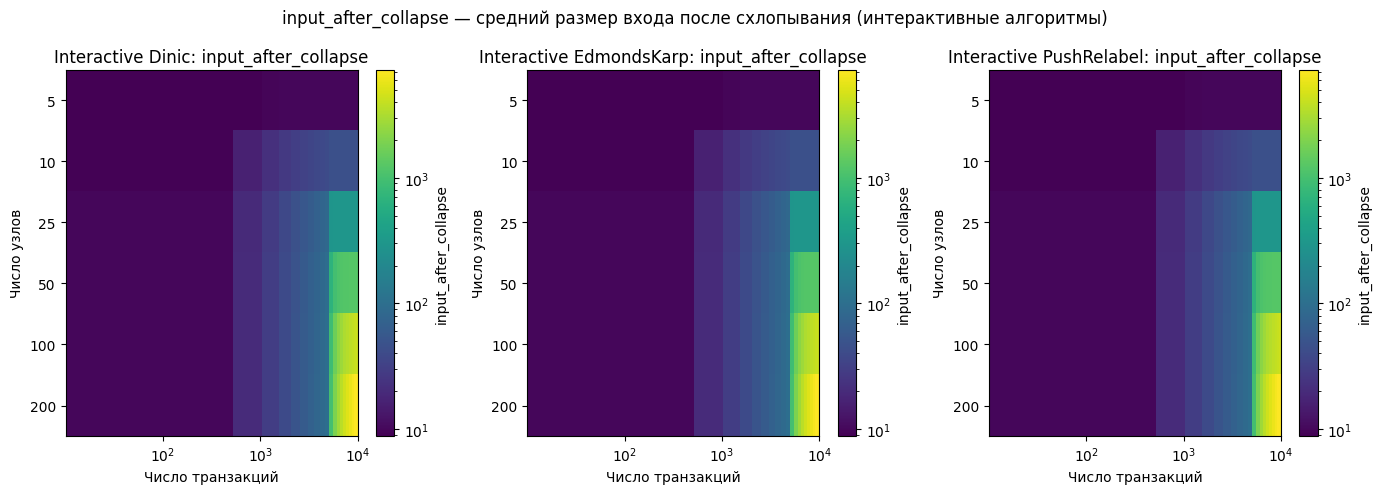

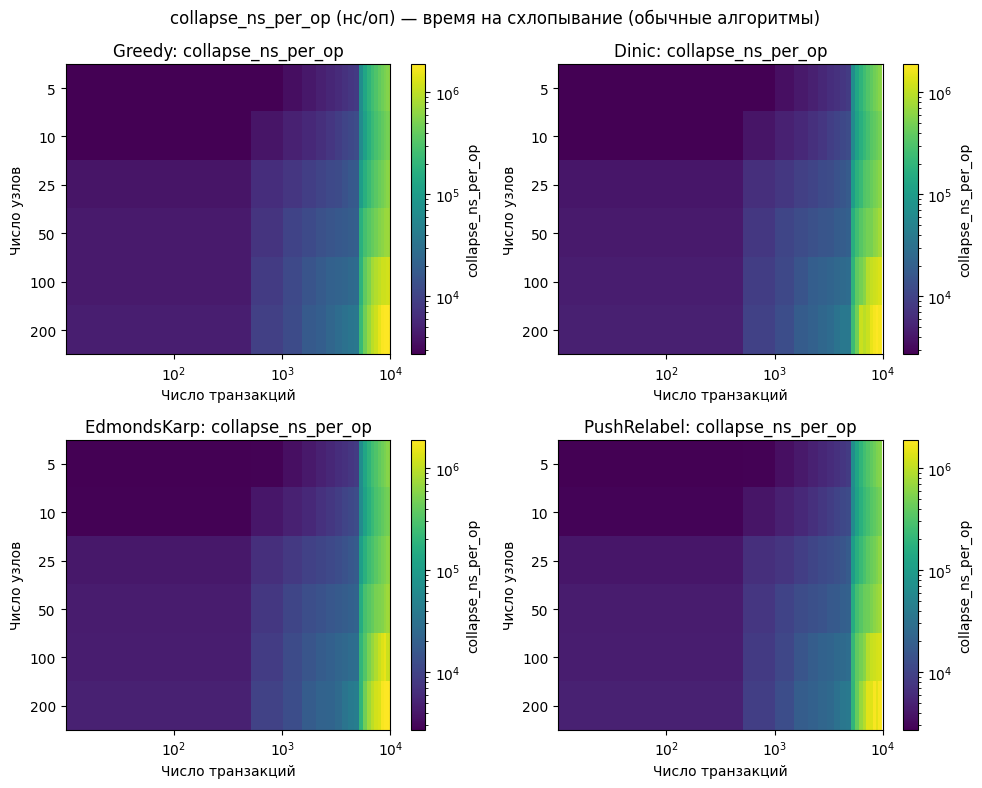

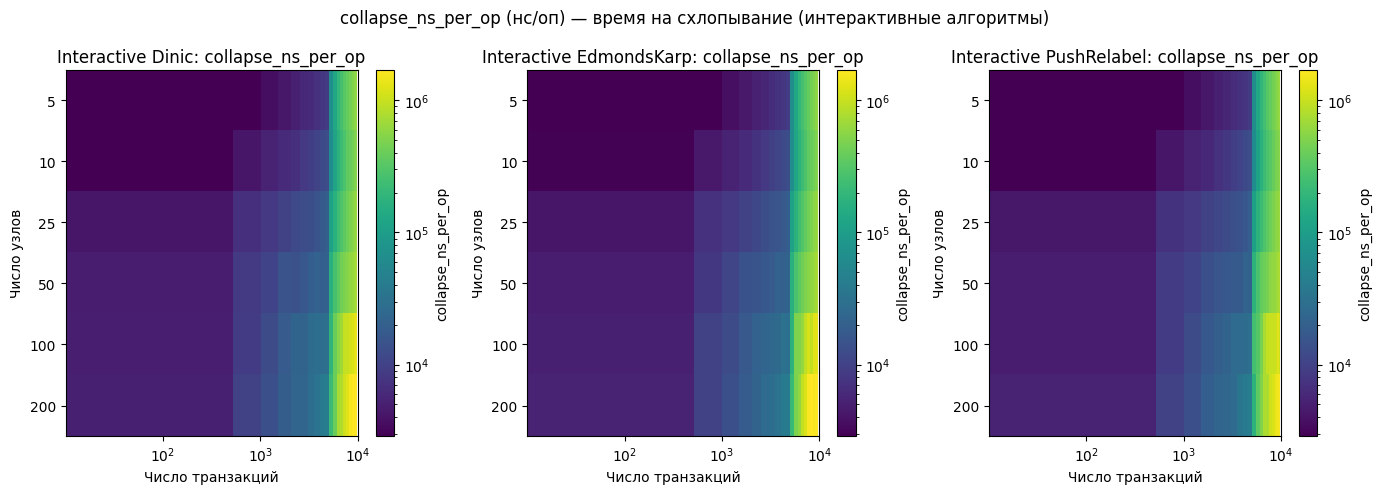

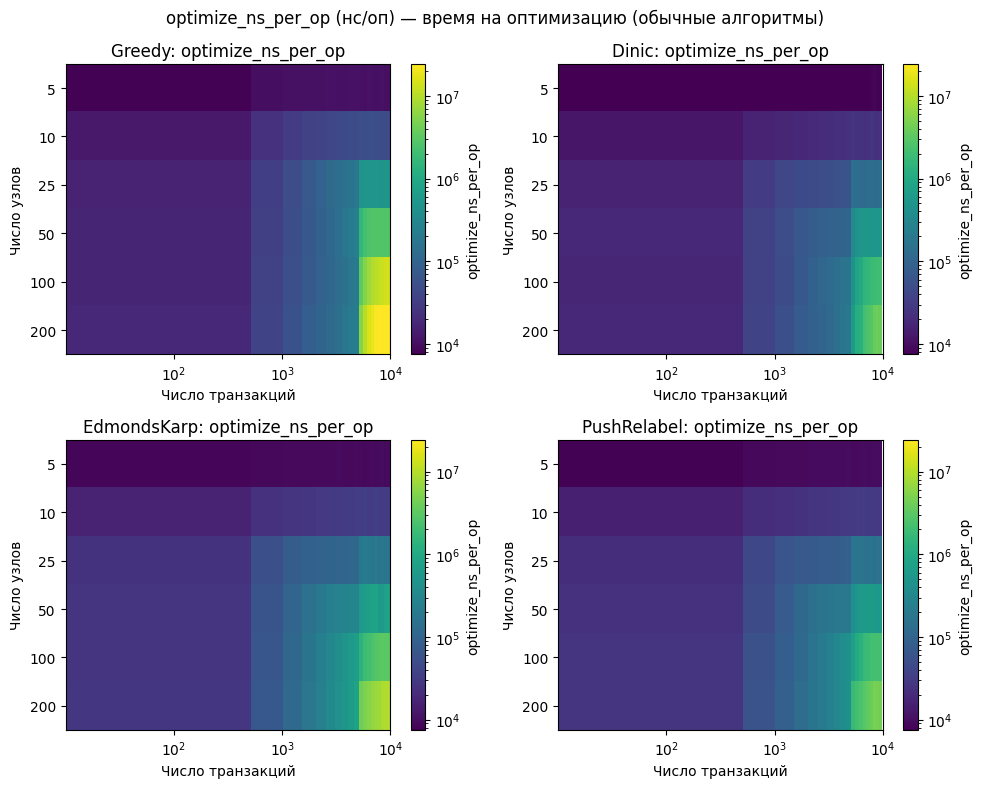

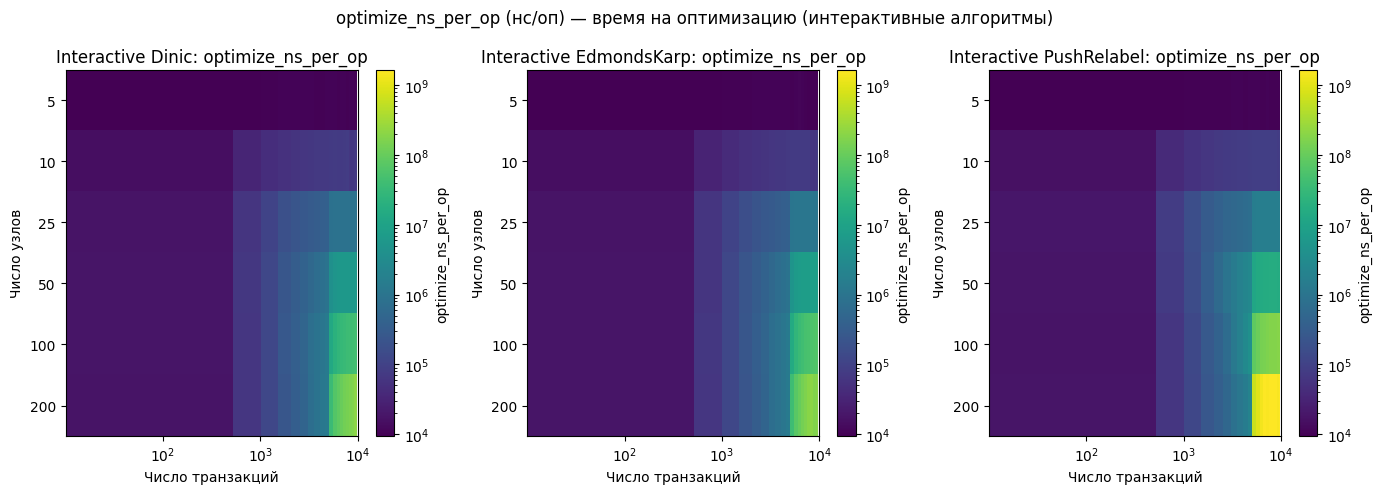

In [107]:
# Блок 4: тепловые карты по дополнительным метрикам (обычные и интерактивные — отдельно)
for metric, title in [
    ("collapse_pct", "collapse_pct (%) — доля схлопнутых транзакций"),
    ("input_after_collapse", "input_after_collapse — средний размер входа после схлопывания"),
    ("collapse_ns_per_op", "collapse_ns_per_op (нс/оп) — время на схлопывание"),
    ("optimize_ns_per_op", "optimize_ns_per_op (нс/оп) — время на оптимизацию"),
]:
    all_vals_r = []
    for algo in ALGOS_REGULAR:
        sub = df_all[df_all["algorithm"] == algo]
        mat = pivot_metric(sub, metric=metric).sort_index(axis=0).sort_index(axis=1)
        if not mat.empty:
            all_vals_r.append(mat.values)
    norm_r = _log_norm(np.concatenate(all_vals_r)) if all_vals_r else LogNorm(1, 10)
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()
    for idx, algo in enumerate(ALGOS_REGULAR):
        sub = df_all[df_all["algorithm"] == algo]
        mat = pivot_metric(sub, metric=metric).sort_index(axis=0).sort_index(axis=1)
        if mat.empty:
            continue
        nodes, trans = mat.index.values, mat.columns.values
        im = axes[idx].imshow(mat.values, aspect="auto", cmap=CMAP_OTHER, norm=norm_r,
                              extent=[trans.min(), trans.max(), nodes.max(), nodes.min()])
        axes[idx].set_xscale("symlog", linthresh=100)
        axes[idx].set_xlabel("Число транзакций")
        axes[idx].set_ylabel("Число узлов")
        axes[idx].set_title(f"{algo}: {metric}")
        set_heatmap_axis_ticks(axes[idx], NODES_SWEEP, TRANS_SWEEP)
        plt.colorbar(im, ax=axes[idx], label=metric)
    plt.suptitle(f"{title} (обычные алгоритмы)")
    plt.tight_layout()
    plt.show()
    all_vals_i = []
    for algo in ALGOS_INTERACTIVE:
        sub = df_all[df_all["algorithm"] == algo]
        mat = pivot_metric(sub, metric=metric).sort_index(axis=0).sort_index(axis=1)
        if not mat.empty:
            all_vals_i.append(mat.values)
    if all_vals_i:
        norm_i = _log_norm(np.concatenate(all_vals_i))
        fig, axes = plt.subplots(1, 3, figsize=(14, 5))
        for idx, algo in enumerate(ALGOS_INTERACTIVE):
            sub = df_all[df_all["algorithm"] == algo]
            mat = pivot_metric(sub, metric=metric).sort_index(axis=0).sort_index(axis=1)
            if mat.empty:
                continue
            nodes, trans = mat.index.values, mat.columns.values
            im = axes[idx].imshow(mat.values, aspect="auto", cmap=CMAP_OTHER, norm=norm_i,
                                  extent=[trans.min(), trans.max(), nodes.max(), nodes.min()])
            axes[idx].set_xscale("symlog", linthresh=100)
            axes[idx].set_xlabel("Число транзакций")
            axes[idx].set_ylabel("Число узлов")
            axes[idx].set_title(f"{algo}: {metric}")
            set_heatmap_axis_ticks(axes[idx], NODES_SWEEP, TRANS_SWEEP)
            plt.colorbar(im, ax=axes[idx], label=metric)
        plt.suptitle(f"{title} (интерактивные алгоритмы)")
        plt.tight_layout()
        plt.show()

## Итог для диплома

По графикам выше: по данным бенчмарка **Dinic** оказывается самым быстрым в большинстве конфигураций (наименьшее среднее время, чаще всего выигрывает по времени). **Greedy** — не самый быстрый и не гарантирует минимальное число транзакций (reduction_len_pct может быть отрицательным). **Edmonds–Karp** даёт оптимальный поток, но медленнее Dinic. Для сервиса оптимизации транзакций разумно выбрать **алгоритм Диница**: оптимальный результат и лучшее время среди трёх.

In [108]:
# Краткая сводка по данным (опционально)
mean_time = df_all.groupby("algorithm")["ns_per_op"].mean()
pivot_time = df_all.pivot_table(index=["nodes", "transactions"], columns="algorithm", values="ns_per_op", aggfunc="mean")
wins = pivot_time.idxmin(axis=1).value_counts()
print("Среднее время (мкс/оп):", (mean_time / 1000).round(1).to_dict())
print("Чаще всего самый быстрый (число конфигураций):", wins.to_dict())

Среднее время (мкс/оп): {'Dinic': 970.6, 'EdmondsKarp': 1546.3, 'Greedy': 3606.8, 'Interactive Dinic': 14723.6, 'Interactive EdmondsKarp': 17282.0, 'Interactive PushRelabel': 143833.3, 'PushRelabel': 1096.3}
Чаще всего самый быстрый (число конфигураций): {'Dinic': 80, 'Greedy': 33, 'PushRelabel': 5, 'EdmondsKarp': 1, 'Interactive Dinic': 1}


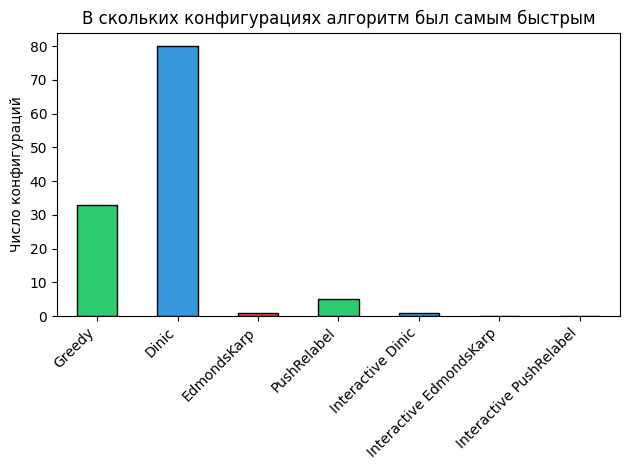

In [112]:
# Дополнительно: кто чаще был самым быстрым (из данных выше)
order = ["Greedy", "Dinic", "EdmondsKarp", "PushRelabel", "Interactive Dinic", "Interactive EdmondsKarp", "Interactive PushRelabel"]
wt = wins.reindex(order, fill_value=0)
wt.plot(kind="bar", color=["#2ecc71", "#3498db", "#e74c3c"], edgecolor="black")
plt.title("В скольких конфигурациях алгоритм был самым быстрым")
plt.ylabel("Число конфигураций")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Что можно вывести из цифр выше (для диплома):**

- **Greedy** — по данным бенчмарка в среднем самый медленный из трёх; **reduction_len_pct** и **reduce_success_pct** у него ниже (часто отрицательный reduction_len_pct). Не гарантирует минимальное число транзакций.
- **Dinic** и **EdmondsKarp** — дают оптимальный поток (минимальное число переводов), поэтому **reduction_len_pct** у них высокий. Dinic при этом быстрее Karp и чаще всего выигрывает по скорости (смотри столбик «кто быстрее» и среднее время).
- **Итог:** для сервиса оптимизации транзакций разумно выбрать **алгоритм Диница**: он даёт оптимальное сокращение транзакций при приемлемой скорости и быстрее Edmonds–Karp. Тепловые карты выше показывают, где именно (по узлам/транзакциям) разница во времени и качестве наиболее заметна.

## Качество оптимизации и валидность

- **reduce_success_pct** — среди валидных запусков доля тех, где число переводов сократилось хотя бы на 1.
- **reduction_len_pct** — средний процент сокращения числа переводов (качество); может быть отрицательным при ухудшении.
- **valid_pct** — среди успешных вызовов оптимизатора доля с валидным результатом (балансы сохранены).

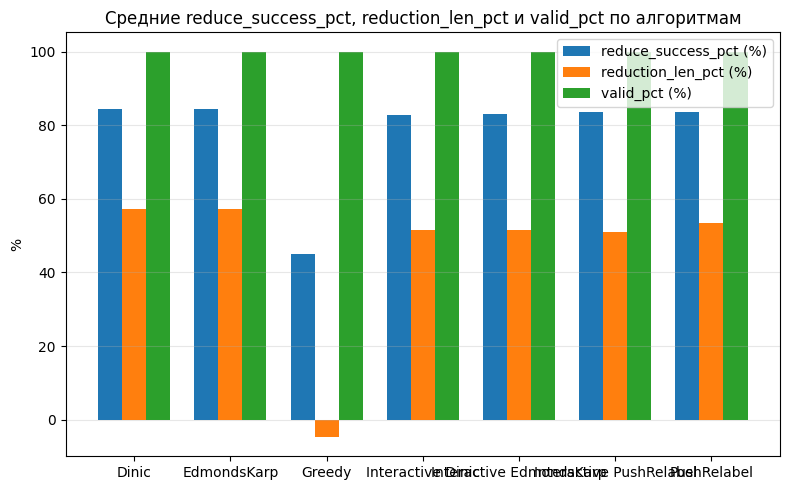

In [110]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# reduce_success_pct, reduction_len_pct и valid_pct по алгоритмам (усреднение по конфигурациям)
agg = df_all.groupby("algorithm").agg({"reduce_success_pct": "mean", "reduction_len_pct": "mean", "valid_pct": "mean"}).reset_index()
x = np.arange(len(agg))
w = 0.25
ax.bar(x - w, agg["reduce_success_pct"], w, label="reduce_success_pct (%)")
ax.bar(x, agg["reduction_len_pct"], w, label="reduction_len_pct (%)")
ax.bar(x + w, agg["valid_pct"], w, label="valid_pct (%)")
ax.set_xticks(x)
ax.set_xticklabels(agg["algorithm"])
ax.set_ylabel("%")
ax.set_title("Средние reduce_success_pct, reduction_len_pct и valid_pct по алгоритмам")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Сводная таблица для диплома

Средние метрики по всем конфигурациям бенчмарка — для краткого сравнения алгоритмов.

In [111]:
summary = df_all.groupby("algorithm").agg({
    "ns_per_op": "mean",
    "collapse_ns_per_op": "mean",
    "optimize_ns_per_op": "mean",
    "reduce_success_pct": "mean",
    "reduction_len_pct": "mean",
    "valid_pct": "mean",
    "bytes_per_op": "mean",
    "allocs_per_op": "mean",
}).round(2)
summary.columns = ["Время (нс/оп)", "collapse (нс/оп)", "optimize (нс/оп)", "reduce_success_pct (%)", "reduction_len_pct (%)", "valid_pct (%)", "Байт/оп", "Аллокаций/оп"]
summary

,Время (нс/оп),collapse (нс/оп),optimize (нс/оп),reduce_success_pct (%),reduction_len_pct (%),valid_pct (%),Байт/оп,Аллокаций/оп
algorithm,,,,,,,,
Dinic,9.706296e+05,314413.42,4.286434e+05,84.33,57.21,100.0,961437.86,3682.99
EdmondsKarp,1.546325e+06,315505.42,9.895943e+05,84.35,57.21,100.0,1579683.30,4585.81
Greedy,3.606843e+06,309963.35,3.144308e+06,45.09,-4.69,100.0,3434201.92,14587.98
Interactive Dinic,1.472364e+07,316738.26,1.413994e+07,82.91,51.48,100.0,26119296.32,251876.98
Interactive EdmondsKarp,1.728203e+07,307434.58,1.672175e+07,82.92,51.48,100.0,31587613.69,264863.02
Interactive PushRelabel,1.438333e+08,282728.03,1.432962e+08,83.56,50.94,100.0,41621962.24,1196329.03
PushRelabel,1.096251e+06,307528.58,5.572106e+05,83.52,53.41,100.0,1061114.84,4687.38


## Выводы для обоснования выбора алгоритма (диплом)

На основе графиков и таблицы можно сформулировать аргументы:

1. **Greedy** — по данным бенчмарка в среднем самый медленный; reduction_len_pct и reduce_success_pct ниже, чем у Dinic/Karp (часто отрицательный reduction_len_pct). Не гарантирует минимальное число транзакций.

2. **Dinic** — оптимальный поток (минимальное число транзакций), по данным бенчмарка самый быстрый в большинстве конфигураций и быстрее Edmonds–Karp; **рекомендуемый выбор для сервиса** при необходимости и оптимальности, и производительности.

3. **Edmonds–Karp** — тоже даёт оптимальный результат, но с большим временем и аллокациями; оправдан, когда важна простота реализации или сравнение с эталоном.

Для сервиса оптимизации транзакций разумно выбрать **алгоритм Диница**: он обеспечивает минимальное количество переводов при сравнимой или лучшей скорости, чем Edmonds–Karp, и умеренном потреблении памяти.